# Vectorized column operations
## Basic column operations


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../06-Exploratory_data_analysis/data/Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Inspect data types
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In Titanic dataset, one row corresponds to one passenger, but each passenger could share a ticket with their family members.

Let's compute total family members for each passenger:
- SibSp: Number of siblings/spouses aboard.
- Parch: Number of parents/children aboard.

In [9]:
# simple basic column arithmetic: Total family members aboard
# + 1 counts the passenger themselves.

df["family_size"] = df["SibSp"] + df["Parch"] + 1
df[["SibSp", "Parch", "family_size"]].head()


,SibSp,Parch,family_size
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


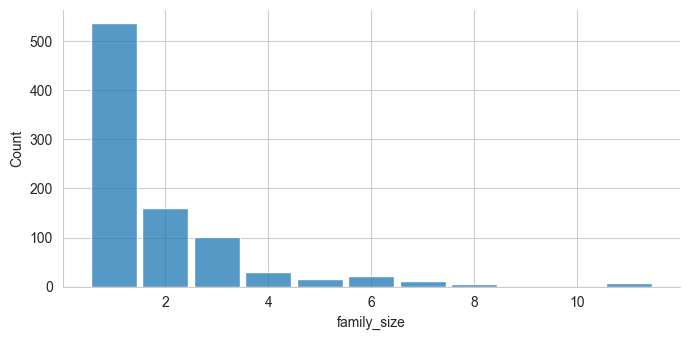

In [26]:
# inspect family sizes
sns.displot(data=df, x="family_size", kind='hist', discrete=True, shrink=0.9,
            height=3.5, aspect=2)

## Arithmetic Between Columns

Fare per family member

In [27]:
df["fare_per_person"] = df["Fare"] / df["family_size"]

df[["Fare", "family_size", "fare_per_person"]].head()


,Fare,family_size,fare_per_person
0,7.2500,2,3.62500
1,71.2833,2,35.64165
2,7.9250,1,7.92500
3,53.1000,2,26.55000
4,8.0500,1,8.05000


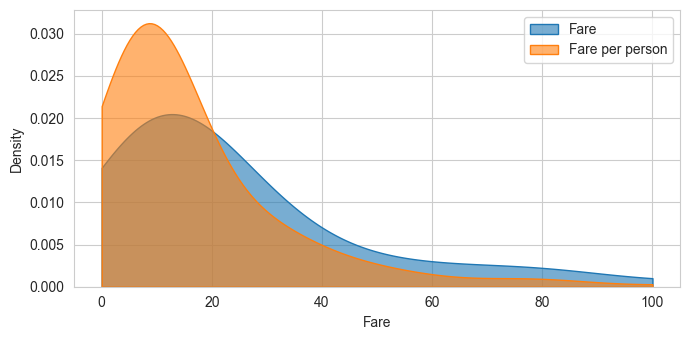

In [47]:
# inspect Fare and fare per person

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 3.5), tight_layout=True)

alpha_ = 0.6

sns.kdeplot(data=df, x="Fare", ax=ax, label='Fare', clip=(0, 100), fill=True, legend=True, alpha=alpha_)
sns.kdeplot(data=df, x="fare_per_person", ax=ax, label="Fare per person", clip=(0, 100), fill=True,legend=True, alpha=alpha_)

ax.legend()

<Axes: xlabel='family_size', ylabel='Fare'>

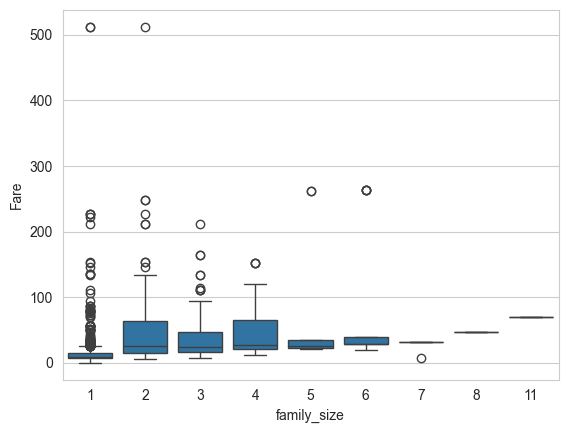

In [51]:
# inspect relationship between fare and family size

sns.boxplot(data=df, x='family_size',y="Fare")

## Using Pandas Methods
`.add(), .sub(), .mul(), .div()`

Same computation using pandas methods:

In [52]:
df["family_size_alt"] = df["SibSp"].add(df["Parch"]).add(1)

df["fare_per_person_alt"] = df["Fare"].div(df["family_size_alt"])

df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,family_size,fare_per_person,family_size_alt,fare_per_person_alt
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,3.62500,2,3.62500
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,35.64165,2,35.64165
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,7.92500,1,7.92500
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,26.55000,2,26.55000
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,8.05000,1,8.05000


## Creating New Columns (feature generation)

### Create a new column by assigning a new Series to the dataframe
Let's create a new feature for each passenger : Is traveling alone

In [54]:
df["is_alone"] = df["family_size"] == 1

df[["family_size", "is_alone"]].head()

,family_size,is_alone
0,2,False
1,2,False
2,1,True
3,2,False
4,1,True


In [55]:
# if we would like numerical instead of boolean

df["is_alone"] = (df["family_size"] == 1).astype(int)

df[["family_size", "is_alone"]].head()


,family_size,is_alone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


Another example: Fare category

In [57]:
df["high_fare"] = (df["Fare"] > 50).astype(int)

df['high_fare'].value_counts()

high_fare
0    731
1    160
Name: count, dtype: int64

### Create a new column using `df.assign()`

Assign new columns to a DataFrame. Returns a new object with all original columns in addition to new ones. Existing columns that are re-assigned will be overwritten.

Very useful for data science pipeline:
- Method chaining
- Dynamic column generation
- Can assign columns using `lambda`
- Dependent assignment: order is preserved, which means, later arguments within a single `assign()` call can refer to columns created earlier in the same call.


In [113]:
df = df.assign(
    family_size = df["SibSp"] + df["Parch"] + 1,
    is_alone = df["family_size"] == 1,
    fare_per_person = lambda x: x['Fare']/x['family_size'],
)

df[['family_size', 'is_alone', 'fare_per_person']].head()


,family_size,is_alone,fare_per_person
0,2,False,3.62500
1,2,False,35.64165
2,1,True,7.92500
3,2,False,26.55000
4,1,True,8.05000


## Boolean Operations

Example: High-class passengers

In [59]:
df["high_class"] = df["Pclass"] == 1

df['high_class'].value_counts()

high_class
False    675
True     216
Name: count, dtype: int64

Combine multiple conditions:
- & = AND
- | = OR

In [60]:
df["rich_and_first_class"] = (df["Fare"] > 100) & (df["Pclass"] == 1)

df[["Fare", "Pclass", "rich_and_first_class"]].head()


,Fare,Pclass,rich_and_first_class
0,7.2500,3,False
1,71.2833,1,False
2,7.9250,3,False
3,53.1000,1,False
4,8.0500,3,False


In [63]:
df["rich_and_first_class_and_travel_alone"] = (df["Fare"] > 100) & (df["Pclass"] == 1) & (df['family_size'] == 1)

df['rich_and_first_class_and_travel_alone'].value_counts()

rich_and_first_class_and_travel_alone
False    875
True      16
Name: count, dtype: int64

In [64]:
df[df['rich_and_first_class_and_travel_alone']]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Embarked,family_size,fare_per_person,family_size_alt,fare_per_person_alt,is_alone,high_fare,high_class,rich_and_first_class,rich_and_first_class_and_travel_alone
195,196,1,1,"Lurette, Miss. Elise",female,58.0,0,0,PC 17569,146.5208,...,C,1,146.5208,1,146.5208,1,1,True,True,True
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,...,C,1,512.3292,1,512.3292,1,1,True,True,True
269,270,1,1,"Bissette, Miss. Amelia",female,35.0,0,0,PC 17760,135.6333,...,S,1,135.6333,1,135.6333,1,1,True,True,True
306,307,1,1,"Fleming, Miss. Margaret",female,NaN,0,0,17421,110.8833,...,C,1,110.8833,1,110.8833,1,1,True,True,True
325,326,1,1,"Young, Miss. Marie Grice",female,36.0,0,0,PC 17760,135.6333,...,C,1,135.6333,1,135.6333,1,1,True,True,True
337,338,1,1,"Burns, Miss. Elizabeth Margaret",female,41.0,0,0,16966,134.5000,...,C,1,134.5000,1,134.5000,1,1,True,True,True
373,374,0,1,"Ringhini, Mr. Sante",male,22.0,0,0,PC 17760,135.6333,...,C,1,135.6333,1,135.6333,1,1,True,True,True
380,381,1,1,"Bidois, Miss. Rosalie",female,42.0,0,0,PC 17757,227.5250,...,C,1,227.5250,1,227.5250,1,1,True,True,True
527,528,0,1,"Farthing, Mr. John",male,NaN,0,0,PC 17483,221.7792,...,S,1,221.7792,1,221.7792,1,1,True,True,True
537,538,1,1,"LeRoy, Miss. Bertha",female,30.0,0,0,PC 17761,106.4250,...,C,1,106.4250,1,106.4250,1,1,True,True,True


In [73]:
print(f"The total survival rate of Titanic passengers was {df['Survived'].sum()*100/df.shape[0]:.2f}%, but the survival rate of passengers who were rich, first class, and travelling alone was as high as {df[df['rich_and_first_class_and_travel_alone']]['Survived'].sum()*100/df['rich_and_first_class_and_travel_alone'].sum()}%.")

The total survival rate of Titanic passengers was 38.38%, but the survival rate of passengers who were rich, first class, and travelling alone was as high as 81.25%.


## String operation - extract titles
(We will talk about more advanced string operations in Demo 0803)

In the Titanic dataset, names look like this:
- Braund, Mr. Owen Harris
- Cumings, Mrs. John Bradley
- Heikkinen, Miss. Laina

Titles such as Mr., Mrs., Miss., Dr., Master contain useful social information.

Explanation of the regex:
- `,`:	Match the comma that appears before the title
- `\s*`:	Match zero or more spaces after the comma
- `( )`:	Capture group (this is what pandas extracts)
- `[^\.]+`:	Match one or more characters that are NOT a period
- `\.`:	Match the period after the title

In [75]:
import re

title_extract_pattern = re.compile(r',\s*([^\.]+)\.')

df["title"] = df["Name"].str.extract(title_extract_pattern)

df[["Name", "title"]].head()


,Name,title
0,"Braund, Mr. Owen Harris",Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs
2,"Heikkinen, Miss. Laina",Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs
4,"Allen, Mr. William Henry",Mr


In [79]:
df['title'].value_counts()

title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64

# Custom Computation with `df.apply()`

- Highly customizable but slower than vectorized operations
- Recommended when logic cannot be expressed with simple vectorized operations
- logic can use one or multiple variables

## Create passenger categories based on gender and age


In [76]:
def passenger_category(row):
    if row["Sex"] == "female":
        if row['Age'] < 18:
            return "girl"
        else:
            return "woman"
    else:
        if row['Age'] < 18:
            return "boy"
        else:
            return "man"

df["passenger_category"] = df.apply(passenger_category, axis=1)# axis=1 means row-wise

df[["Sex", "Age", "passenger_category"]].head()


,Sex,Age,passenger_category
0,male,22.0,man
1,female,38.0,woman
2,female,26.0,woman
3,female,35.0,woman
4,male,35.0,man


In [78]:
df['passenger_category'].value_counts(dropna=False)

passenger_category
man      519
woman    259
boy       58
girl      55
Name: count, dtype: int64

## Passenger risk level


In [92]:
def risk_level(row):
    if row["Pclass"] == 3 and row["Age"] > 50:
        return "High Risk"
    elif row["Pclass"] == 1:
        return "Low Risk"
    else:
        return "Medium Risk"

df["risk_level"] = df.apply(risk_level, axis=1)
df['risk_level'] = df['risk_level'].astype(pd.CategoricalDtype(categories=["Low Risk", 'Medium Risk', 'High Risk'],ordered=True))

df[["Pclass", "Age", "risk_level"]].head()


,Pclass,Age,risk_level
0,3,22.0,Medium Risk
1,1,38.0,Low Risk
2,3,26.0,Medium Risk
3,1,35.0,Low Risk
4,3,35.0,Medium Risk


In [94]:
df['risk_level'].value_counts(sort=False)

risk_level
Low Risk       216
Medium Risk    665
High Risk       10
Name: count, dtype: int64

In [99]:
df.groupby('risk_level', as_index=False, observed=False)['Survived'].value_counts(normalize=True).query("Survived == 1")

,risk_level,Survived,proportion
0,Low Risk,1,0.629630
3,Medium Risk,1,0.308271
5,High Risk,1,0.100000


<Axes: xlabel='Survived', ylabel='proportion'>

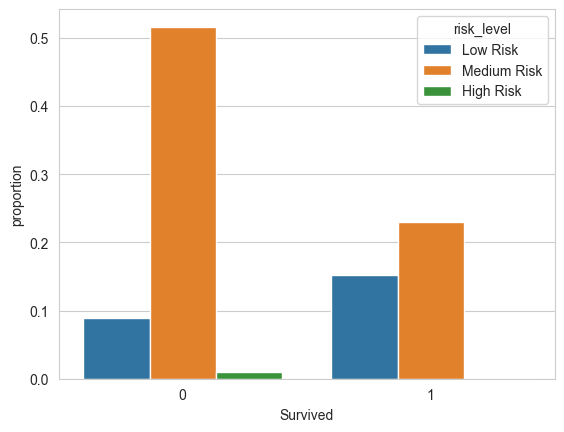

In [102]:
sns.countplot(data=df, x='Survived', hue='risk_level', stat='proportion')